In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('./MNRAS.mplstyle')

import os, glob
import h5py

In [2]:
##########     lensing;  Compton-y w/o, w/ noise; Sigma_g: n_g= 0.01, 0.001
OBS_LIST = ["DS", "Sigma", "cy", "ns_cy", "sigg_hd", "sigg_ld"]

def load_one_file(path, obs_list=OBS_LIST):
    """Read all requested observables from one HDF5 into a dict."""
    out = {}
    with h5py.File(path, "r") as f:
        meta = dict(f.attrs.items())
        rp = f["rp"][:] if "rp" in f else None

        out["meta"] = meta
        out["rp"] = rp

        for obs in obs_list:
            g = f[f"results/{obs}"]
            out[obs] = {
                "bias_sim":     g["bias_sim"][:],       # Simulation with shape (richness_bins=4, Nrp=20)
                "bias_sim_err": g["bias_sim_err"][:],   # based on error propagation 
                "bias_eq8":     g["bias_eq8"][:],       # Analytic ratios based on Eq.(8) in Wu+2022
                "bias_eq8_err": g["bias_eq8_err"][:],   # based on error propagation 
                # optional
                "obs_mean":     g["obs_mean"][:],
                "obs_err":      g["obs_err"][:],
                "exp_mean":     g["exp_mean"][:],
                "exp_err":      g["exp_err"][:],
                "eq8_pred":     g["eq8_pred"][:],       
                "eq8_base":     g["eq8_base"][:],
                "n_sel":        g["n_sel"][:],          # (4,)
                "lam_min":      g["lam_min"][:],        # CIC richness
                "lam_max":      g["lam_max"][:],
                "m_min":        g["m_min"][:],          # halo_mass (M_500c, Msun/h)
                "m_max":        g["m_max"][:],
            }
    return out


def merge_bias_directory(outdir, pattern="wu22_eq8_*_mz20.h5", obs_list=OBS_LIST,
                         Ng=7, Nq=5, Nr=4, Nrp_expected=20,
                         require_all=False):
    """
    Merge many per-task HDF5 into dense arrays:
      data[obs][field] -> (Ng, Nq, Nr, Nrp)
    Missing (gal,q) combos are left as NaN.

    require_all=False: allow missing files, just keep NaNs.
    """
    files = sorted(glob.glob(os.path.join(outdir, pattern)))
    if len(files) == 0:
        raise FileNotFoundError(f"No files found in {outdir} matching {pattern}")

    # allocate containers
    data = {obs: {} for obs in obs_list}
    fields_4d = ["bias_sim", "bias_sim_err", "bias_eq8", "bias_eq8_err",
                 "obs_mean", "obs_err", "exp_mean", "exp_err", "eq8_pred", "eq8_base"]
    fields_3d = ["n_sel", "lam_min", "lam_max", "m_min", "m_max"]  # (Ng,Nq,Nr)

    for obs in obs_list:
        for fld in fields_4d:
            data[obs][fld] = np.full((Ng, Nq, Nr, Nrp_expected), np.nan, dtype=float)
        for fld in fields_3d:
            data[obs][fld] = np.full((Ng, Nq, Nr), np.nan, dtype=float)

    rp_ref = None
    present = np.zeros((Ng, Nq), dtype=bool)
    meta_grid = [[None for _ in range(Nq)] for _ in range(Ng)]

    for path in files:
        d = load_one_file(path, obs_list=obs_list)
        meta = d["meta"]

        gal_idx = int(meta.get("gal_idx"))
        q_depth = int(meta.get("cyl_depth"))

        # cyl_depth value and its index
        cyl_depth_list = [1, 180] #Units: cMpc/h; all cyls: [1, 30, 60, 90, 120, 180]
        if q_depth not in cyl_depth_list:
            print(f"[skip] unknown cyl_depth {q_depth} in {os.path.basename(path)}")
            continue
        q_idx = cyl_depth_list.index(q_depth)

        # rp consistency check
        rp = d["rp"]
        if rp_ref is None:
            rp_ref = rp
            if len(rp_ref) != Nrp_expected:
                print(f"[warn] rp has length {len(rp_ref)} not {Nrp_expected}; updating expected.")
        else:
            if (rp is None) or (len(rp) != len(rp_ref)) or (np.max(np.abs(rp - rp_ref)) > 0):
                raise ValueError(f"rp mismatch in file: {path}")

        present[gal_idx, q_idx] = True
        meta_grid[gal_idx][q_idx] = meta

        for obs in obs_list:
            for fld in fields_4d:
                arr = d[obs][fld]   # (Nr, Nrp)
                if arr.shape != (Nr, Nrp_expected):
                    raise ValueError(f"{obs}/{fld} shape {arr.shape} != {(Nr, Nrp_expected)} in {path}")
                data[obs][fld][gal_idx, q_idx, :, :] = arr

            for fld in fields_3d:
                arr = d[obs][fld]   # (Nr,)
                if arr.shape != (Nr,):
                    raise ValueError(f"{obs}/{fld} shape {arr.shape} != {(Nr,)} in {path}")
                data[obs][fld][gal_idx, q_idx, :] = arr

    if require_all and not np.all(present):
        missing = np.argwhere(~present)
        raise RuntimeError(f"Missing {missing.shape[0]} (gal,q) combos. First few: {missing[:10]}")

    return rp_ref, data, present, meta_grid


# bias_data directory path, which should include two files:
# *** ONLY *** include projection_depth = 300 cMpc/h for lensing, cy, and sigg
# "wu22_eq8_gal1_q180_proj300_chi6_mz20.h5" 
# "wu22_eq8_gal1_q1_proj300_chi6_mz20.h5"
OUTDIR = "bias_data" 
rp, data, present, meta_grid = merge_bias_directory(OUTDIR)

print("rp:", rp[:5], "...", rp[-3:])
print("present files:", present.sum(), "out of", present.size)

# "wu22_eq8_gal1_q180_proj1_chi6_mz20_new.h5"
# *** ONLY *** includes projection_depth = 1 cMpc/h for lensing, cy, and sigg
_, data_1h, present_1h, _ = merge_bias_directory(OUTDIR, "wu22_eq8_gal1_q180_proj1_*_new.h5")
print("present files:", present_1h.sum(), "out of", present_1h.size)


rp: [0.11532621 0.15338543 0.20400469 0.271329   0.36087125] ... [14.7055441  19.55857279 26.01316666]
present files: 2 out of 35
present files: 1 out of 35


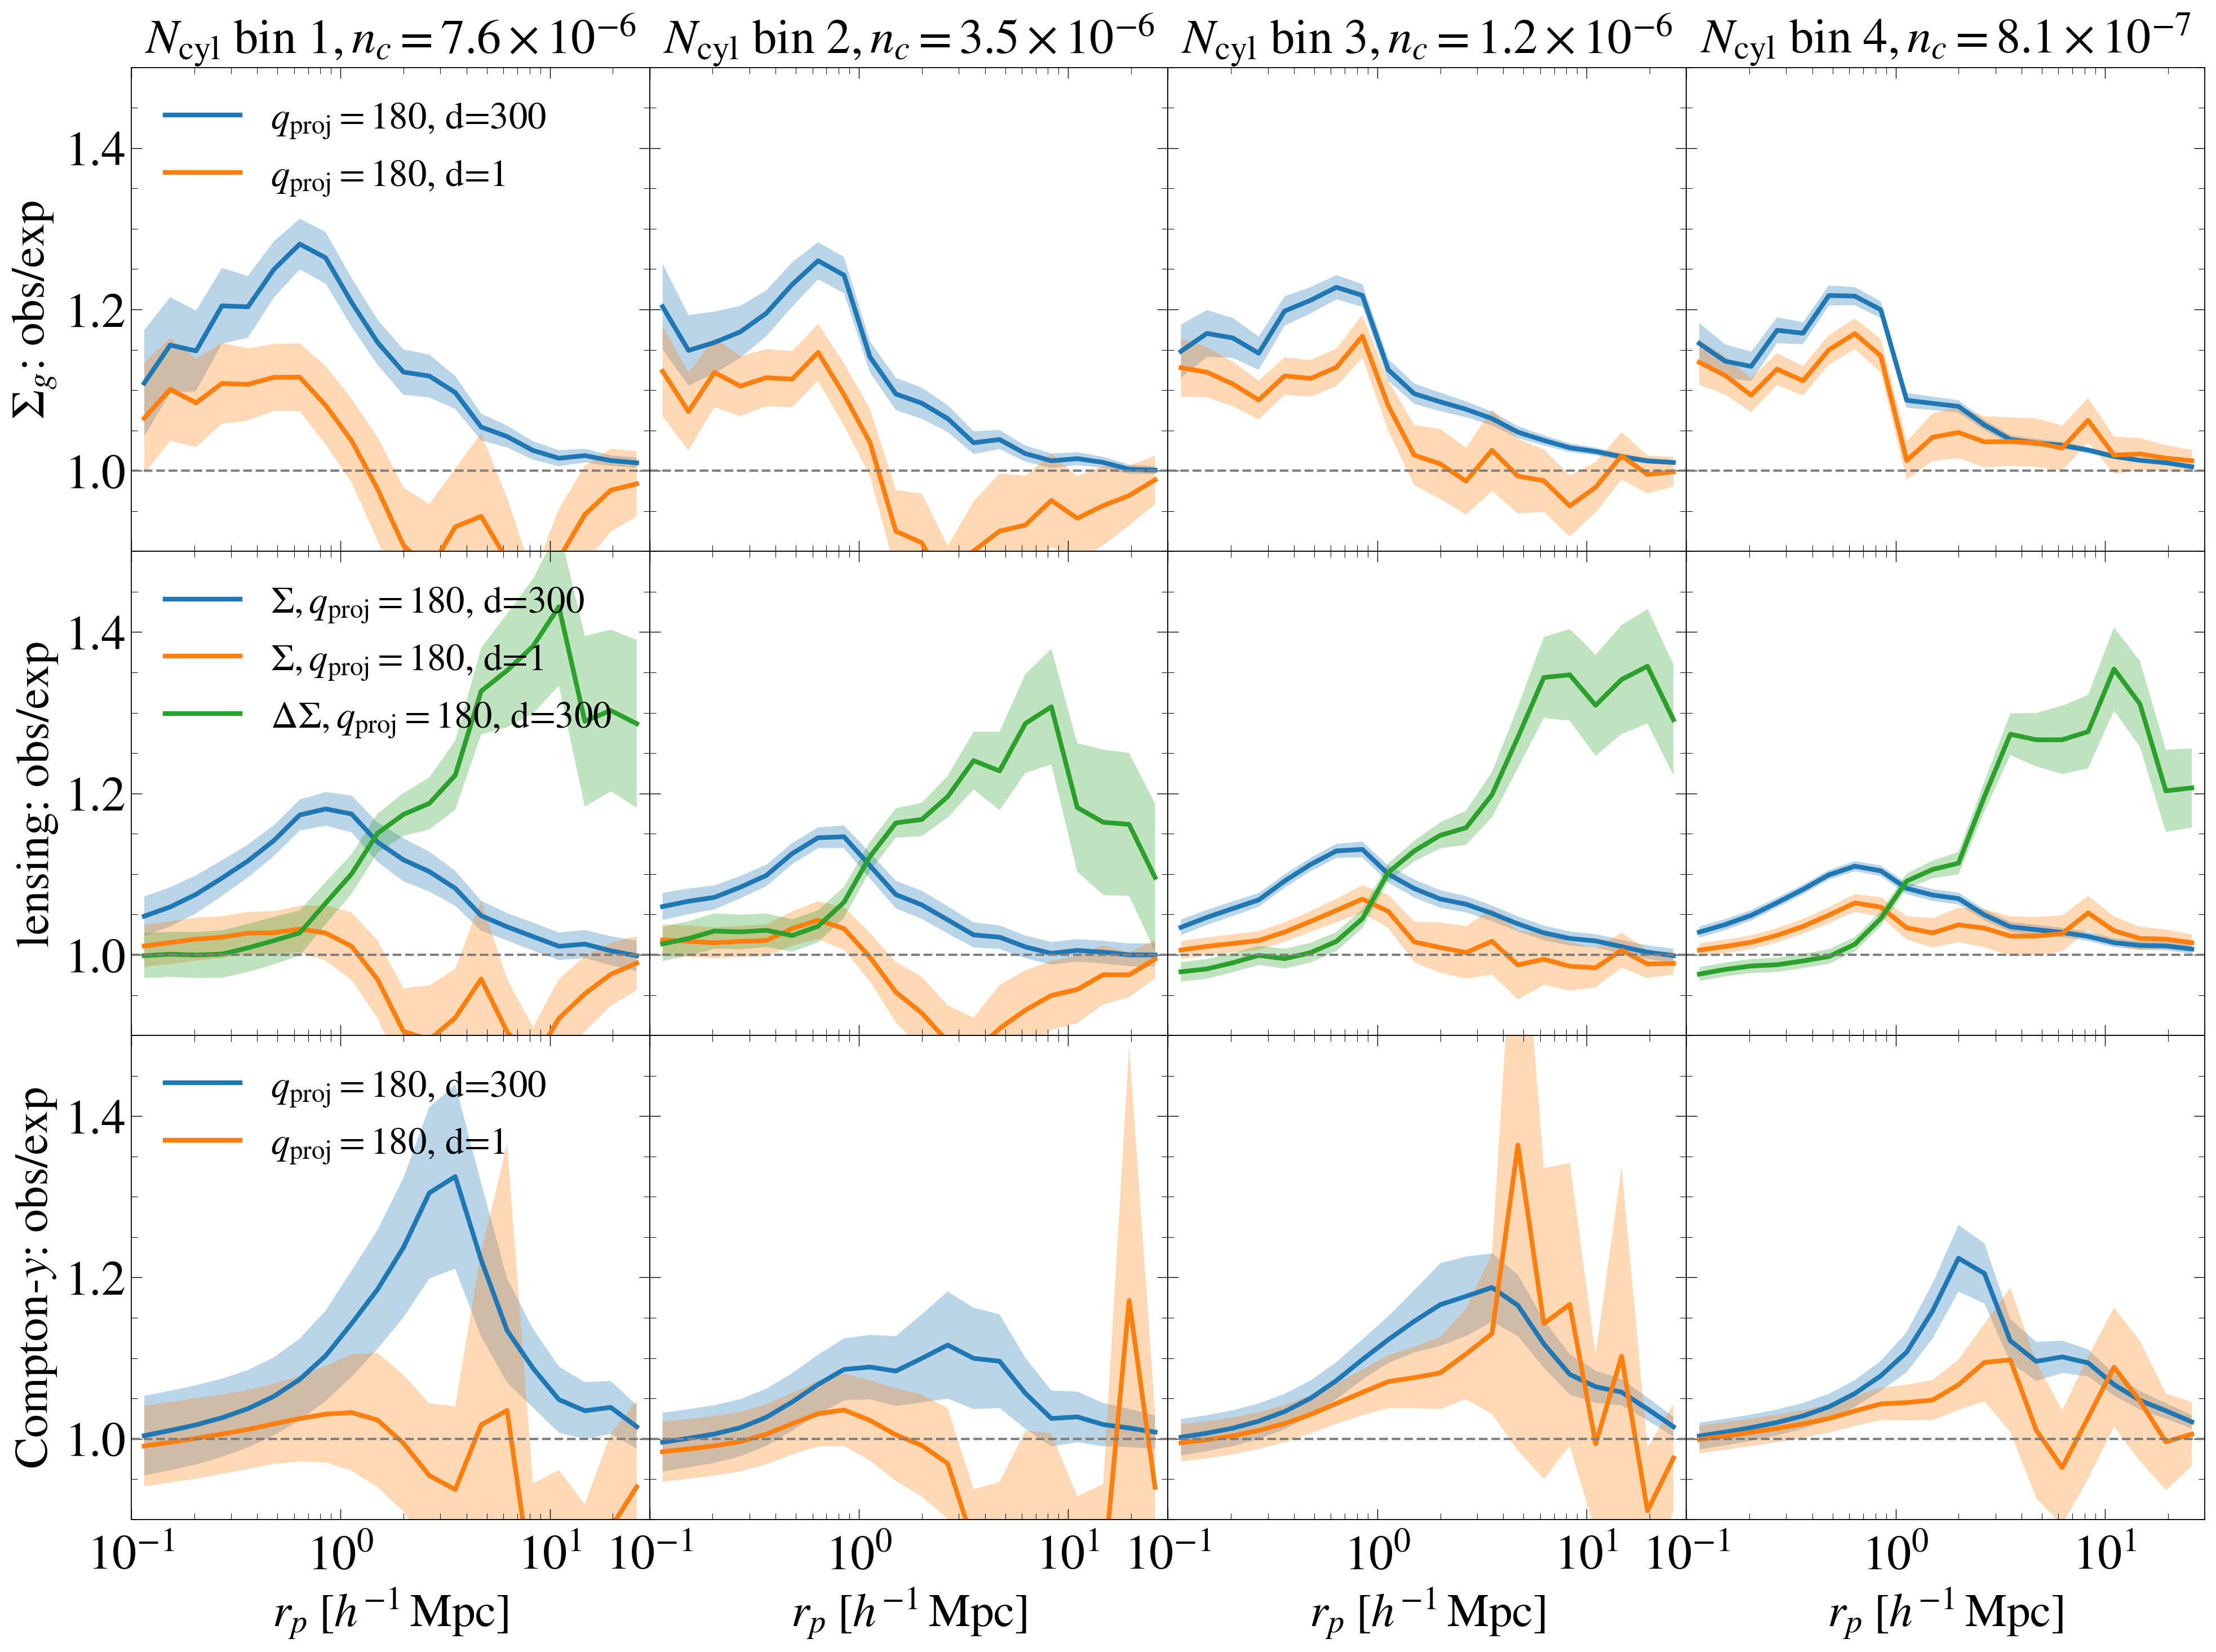

In [10]:
numlam_DESY3 = np.array([257, 370, 1103, 2396])  # DES Y3 (AM) cluster counts in four richness bins 
num_clus_used = numlam_DESY3[::-1]
####### filename: gal0,  gal1, ...                                             gal6
#gal_dens = ["1.2e-02", "1.0e-02", "8.0e-03", "6.0e-03", "4.0e-03", "2.0e-03", "1.0e-03"]
#gal_dens_num = [1.2e-2, 1e-2, 8e-3, 6e-3, 4e-3, 2e-3, 1e-3]



#### richness selected sample
# use n_g = 1e-2 for all panels
# only use N_cyl q=180
# for Sigma_g,  Sigma, and y: full projection (same as before) and 1-halo (1 Mpc)


fig, axes = plt.subplots(
    nrows=3, ncols=4,
    figsize=(20, 15),
    sharex=True,
    gridspec_kw = {'wspace':0, 'hspace':0}
    , sharey='row',
)

col_titles = [
    r"$N_{\rm cyl} {\rm ~bin ~1}, n_c = 7.6\times10^{-6}$",  # Hard coded to show 10^{-6}
    r"$N_{\rm cyl} {\rm ~bin ~2}, n_c = 3.5\times10^{-6}$",
    r"$N_{\rm cyl} {\rm ~bin ~3}, n_c = 1.2\times10^{-6}$",
    r"$N_{\rm cyl} {\rm ~bin ~4}, n_c = 8.1\times10^{-7}$",
]

row_ylabels = [
    r"$\Sigma_g$: obs/exp",
    r"lensing: obs/exp",
    r"Compton-$y$: obs/exp",
]

# obs_rows = ["DS", "Sigma", "cy", "ns_cy", "sigg_hd", "sigg_ld"]
gal_idx_fixed = 1 #  gal_num_dens for CIC richness "1.0e-02"
q_cyl_1 = 0
q_cyl_180 = 1
q_cyl_1h = 1 ## q_cyl=180 (richness); d_proj=1 (sigg/lensing/cy)

Vol_flamingo = (681.0)**3

for col, title in enumerate(col_titles):
    axes[0, col].set_title(title)# + rf"${(num_clus_used[col]/Vol_flamingo):.2e}$")

for row, ylabel in enumerate(row_ylabels):
    axes[row, 0].set_ylabel(ylabel)

for col in range(4):
    axes[2, col].set_xlabel(r"$r_p \; [h^{-1}\,\mathrm{Mpc}]$")

for row in range(3):
    for col in range(4):
        rich_bin = col

        ax = axes[row, col]
        if row == 0:  # galaxy distribution

            # Sigma_g with gal_cats 1e-02; "sigg_ld" with gal_cats 1e-03
            y_sim = data["sigg_hd"]["bias_sim"][gal_idx_fixed, q_cyl_180, rich_bin, :]
            e_sim = data["sigg_hd"]["bias_sim_err"][gal_idx_fixed, q_cyl_180, rich_bin, :]
            
            line = ax.plot(rp, y_sim, lw=3, label=r"$q_{\rm proj}=180$, d=300")
            ax.fill_between(rp, y_sim-e_sim, y_sim+e_sim, interpolate=True, facecolor=line[0].get_c(), alpha=0.3)

            ##### TODO: 1-halo only
            y_sim = data_1h["sigg_hd"]["bias_sim"][gal_idx_fixed, q_cyl_1h, rich_bin, :]
            e_sim = data_1h["sigg_hd"]["bias_sim_err"][gal_idx_fixed, q_cyl_1h, rich_bin, :]
            
            line = ax.plot(rp, y_sim, lw=3, label=r"$q_{\rm proj}=180$, d=1")
            ax.fill_between(rp, y_sim-e_sim, y_sim+e_sim, interpolate=True, facecolor=line[0].get_c(), alpha=0.3)
            
        if row == 1:  # lensing

            # Full projection   
            y_sim = data["Sigma"]["bias_sim"][gal_idx_fixed, q_cyl_180, rich_bin, :]
            e_sim = data["Sigma"]["bias_sim_err"][gal_idx_fixed, q_cyl_180, rich_bin, :]
            
            line = ax.plot(rp, y_sim, lw=3, label=r"$\Sigma, q_{\rm proj}=180$, d=300")
            ax.fill_between(rp, y_sim-e_sim, y_sim+e_sim, interpolate=True, facecolor=line[0].get_c(), alpha=0.3)


            # 1-halo only
            y_sim = data_1h["Sigma"]["bias_sim"][gal_idx_fixed, q_cyl_1h, rich_bin, :]
            e_sim = data_1h["Sigma"]["bias_sim_err"][gal_idx_fixed, q_cyl_1h, rich_bin, :]
            
            line = ax.plot(rp, y_sim, lw=3, label=r"$\Sigma, q_{\rm proj}=180$, d=1")
            ax.fill_between(rp, y_sim-e_sim, y_sim+e_sim, interpolate=True, facecolor=line[0].get_c(), alpha=0.3)

            # Delta Sigma          
            y_sim = data["DS"]["bias_sim"][gal_idx_fixed, q_cyl_180, rich_bin, :]
            e_sim = data["DS"]["bias_sim_err"][gal_idx_fixed, q_cyl_180, rich_bin, :]

            line = ax.plot(rp, y_sim, lw=3, label=r"$\Delta\Sigma, q_{\rm proj}=180$, d=300") #no q=1 to avoid clutter
            ax.fill_between(rp, y_sim-e_sim, y_sim+e_sim, interpolate=True, facecolor=line[0].get_c(), alpha=0.3)

        if row == 2:  # SZ
            # Full projection    
            y_sim = data["cy"]["bias_sim"][gal_idx_fixed, q_cyl_180, rich_bin, :]
            e_sim = data["cy"]["bias_sim_err"][gal_idx_fixed, q_cyl_180, rich_bin, :]

            line = ax.plot(rp, y_sim, lw=3, label=r"$q_{\rm proj}=180$, d=300")
            ax.fill_between(rp, y_sim-e_sim, y_sim+e_sim, interpolate=True, facecolor=line[0].get_c(), alpha=0.3)

            # 1-halo only
            y_sim = data_1h["cy"]["bias_sim"][gal_idx_fixed, q_cyl_1h, rich_bin, :]
            e_sim = data_1h["cy"]["bias_sim_err"][gal_idx_fixed, q_cyl_1h, rich_bin, :]
            
            line = ax.plot(rp, y_sim, lw=3, label=r"$q_{\rm proj}=180$, d=1")
            ax.fill_between(rp, y_sim-e_sim, y_sim+e_sim, interpolate=True, facecolor=line[0].get_c(), alpha=0.3)

        ax.axhline(1, c='gray', ls='--')
        ax.set_ylim(0.9, 1.5)
        ax.set_xlim(0.1, 30)
        ax.set_xscale('log')        
        if col==0:
            ax.legend(loc=2)#, fontsize=18)
        ax.grid(False)
plt.savefig('../plots/richness_selection_1halo.pdf')